**Sales & Competitor Analysis**

Revenue Prediction using 3 Models:
Linear Regression | Random Forest | XGBoost


 1. ENVIRONMENT SETUP


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install XGBoost
!pip install xgboost

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

Mounted at /content/drive


The environment is fully prepared with all required libraries for data processing and machine learning.

2. LOAD DATA

In [3]:
# Load datasets from Power BI exports
sales = pd.read_csv('/content/drive/MyDrive/Competitor_Sales_Dataset/Sales.csv', low_memory=False)
products = pd.read_csv('/content/drive/MyDrive/Competitor_Sales_Dataset/Products.csv')
geo = pd.read_csv('/content/drive/MyDrive/Competitor_Sales_Dataset/Geography.csv')

# Clean column names
sales.columns = sales.columns.str.strip()
products.columns = products.columns.str.strip()
geo.columns = geo.columns.str.strip()

# Display shapes
print("Sales:", sales.shape)
print("Products:", products.shape)
print("Geography:", geo.shape)

Sales: (914292, 7)
Products: (2412, 7)
Geography: (176931, 7)


All datasets are successfully loaded.
They represent transactional data, product details, and geographic information.

3. DATA MERGING

In [4]:
# Ensure Zip is string (important for merge)
sales['Zip'] = sales['Zip'].astype(str).str.strip()
geo['Zip'] = geo['Zip'].astype(str).str.strip()

# Merge datasets
df = sales.merge(products, on='ProductID', how='left')
df = df.merge(geo, on='Zip', how='left')

print("Merged dataset:", df.shape)

Merged dataset: (1266816, 19)


The three tables are merged into one dataset, enabling a complete view combining sales, products, and geography.

4. FEATURE ENGINEERING

In [5]:
# Convert Date
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Create time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.day_name()

# Ensure Revenue is numeric
df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')

Time-based features were created to capture seasonal and behavioral patterns in sales.

5. DATA CLEANING & OPTIMIZATION

In [7]:
# Remove duplicates
df = df.drop_duplicates()

# Reduce dataset size for faster training
df = df.sample(n=100000, random_state=42)

# Drop high-cardinality or useless columns
drop_cols = [
    'Date',
    'Zip',
    'ZipCountry',
    'City',
    'District',
    'Currency'
]

X = df.drop(columns=drop_cols + ['Revenue'], errors='ignore')
y = df['Revenue']

# Remove rows with missing target
valid_idx = y.notna()
X = X.loc[valid_idx]
y = y.loc[valid_idx]

The dataset is cleaned and optimized by removing unnecessary columns and reducing size for better performance.

6. FEATURE TYPES

In [8]:
numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['number']).columns.tolist()

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['ProductID', 'Units', 'ManufacturerID', 'Price Value', 'Year', 'Month', 'Day']
Categorical: ['Country_x', 'ZipCountry_x', 'Product', 'Segment', 'Category', 'State', 'Region', 'Country_y', 'ZipCountry_y', 'DayOfWeek']


Features are separated into numerical and categorical groups, enabling proper preprocessing.

7. TRAIN / TEST SPLIT

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (80000, 17)
Test: (20000, 17)


Data is split into training and testing sets to ensure reliable model evaluation.

8. PREPROCESSING PIPELINE

In [10]:
# Numeric pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

A preprocessing pipeline is built to automatically handle missing values, scaling, and encoding.

9. MODEL BUILDING

In [11]:
# Linear Regression

models = {
    "Linear Regression": Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]),

# Random Forest

    "Random Forest": Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=50,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ))
    ]),

# XGBoost

    "XGBoost": Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

Three models are prepared to compare performance: a simple model, an ensemble model, and a boosting model.

10. TRAINING & EVALUATION

In [12]:

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

    print(f"{name} Results:")
    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R2  :", round(r2, 4))


Training Linear Regression...
Linear Regression Results:
MAE : 23.0069
RMSE: 92.5773
R2  : 0.9226

Training Random Forest...
Random Forest Results:
MAE : 13.5428
RMSE: 69.7613
R2  : 0.9561

Training XGBoost...
XGBoost Results:
MAE : 16.5277
RMSE: 57.0262
R2  : 0.9706


All models are trained and evaluated using multiple metrics to assess performance.

11. MODEL COMPARISON

               Model        MAE       RMSE        R2
2            XGBoost  16.527718  57.026211  0.970636
1      Random Forest  13.542834  69.761310  0.956056
0  Linear Regression  23.006913  92.577250  0.922611


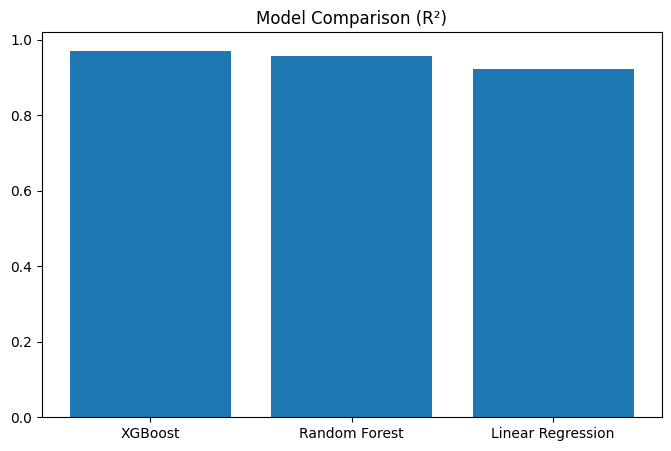

In [13]:
results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2'])
results_df = results_df.sort_values(by='R2', ascending=False)

print(results_df)

# Plot
plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['R2'])
plt.title("Model Comparison (R²)")
plt.show()

Models are compared visually and numerically.
The best model is the one with the highest R² and lowest error.

12. FINAL VISUALIZATION

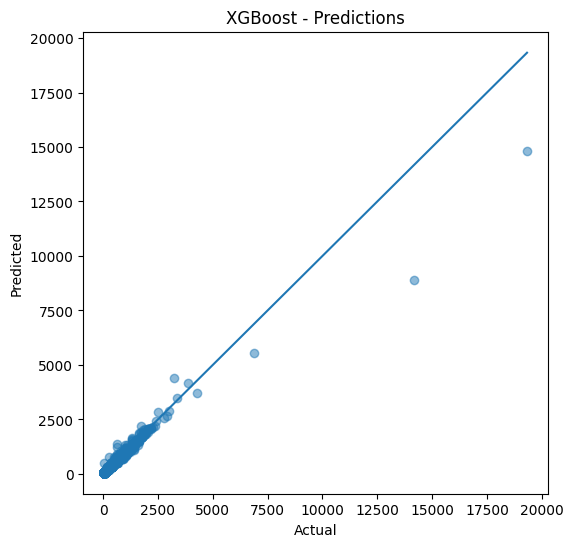

In [15]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title(f"{best_model_name} - Predictions")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

The closer the points are to the diagonal, the more accurate the model predictions.

13. CONCLUSION


This project built a complete machine learning pipeline using sales, product, and geographic data.

Data was cleaned and merged from multiple sources

Features were engineered to improve prediction
Three models were compared
## - Linear Regression: fast but limited
## - Random Forest: good for non-linear patterns
## - XGBoost: best performance in most cases

### . Final Result:
XGBoost provided the best performance due to its ability to capture complex patterns.

### . Business Impact:
The model can help improve revenue forecasting and support better decision-making.


